# Programming for AI Terminal Project
### Submitted by: Amina Riaz (SP24-BAI-007), Rdan Tufail (SP24-BAI-044)


### Cell # 01: Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

### Cell # 02: Loading Dataset

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame


df.rename(columns={'target': 'Outcome'}, inplace=True)


X = df.drop("Outcome", axis=1)
y = df["Outcome"]

### Cell # 03: Target Class Balance:

In [3]:
#The dataset is slightly imbalances as:
print("Target Class Balance")
print(y.value_counts(normalize=True)*100)

Target Class Balance
Outcome
1    62.741652
0    37.258348
Name: proportion, dtype: float64


### Basic EDA:

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.shape

(569, 31)

In [6]:
print(f"Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns")
print("Target Class Balance:")
print(y.value_counts(normalize=True) * 100) #Target class is slightly imbalanced but it is common and is unlikely to cause perfromance issues.

Dataset Size: 569 rows, 31 columns
Target Class Balance:
Outcome
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64

In [9]:
a=len(df)
df.drop_duplicates(inplace=True)
b=len(df)
if a==b:
    print("No duplicate rows")
else:
    print(a-b," duplicate rows removed succesfully")

No duplicate rows


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [11]:
Q1=X.quantile(0.25)
Q3=X.quantile(0.75)
IQR=Q3-Q1
outliers=((X<(Q1-1.5*IQR))|(X>(Q3+1.5*IQR)))
print("Number of outliers per column: ", outliers.sum())
mask=outliers.any(axis=1)
df=df[~mask].copy()
len(df)

Number of outliers per column:  mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64


398

In [12]:
df.shape

(398, 31)

Outliers should have been handled by imputing the median values in place of outliers as dataset is small and removing the rows containing outliers reduce the datset size or total number of rows for training and testing but the rows containg outliers have been removed from here for the sake of simplicity.

### Deeper EDA (Visualizations)
>### Correlation Matrix

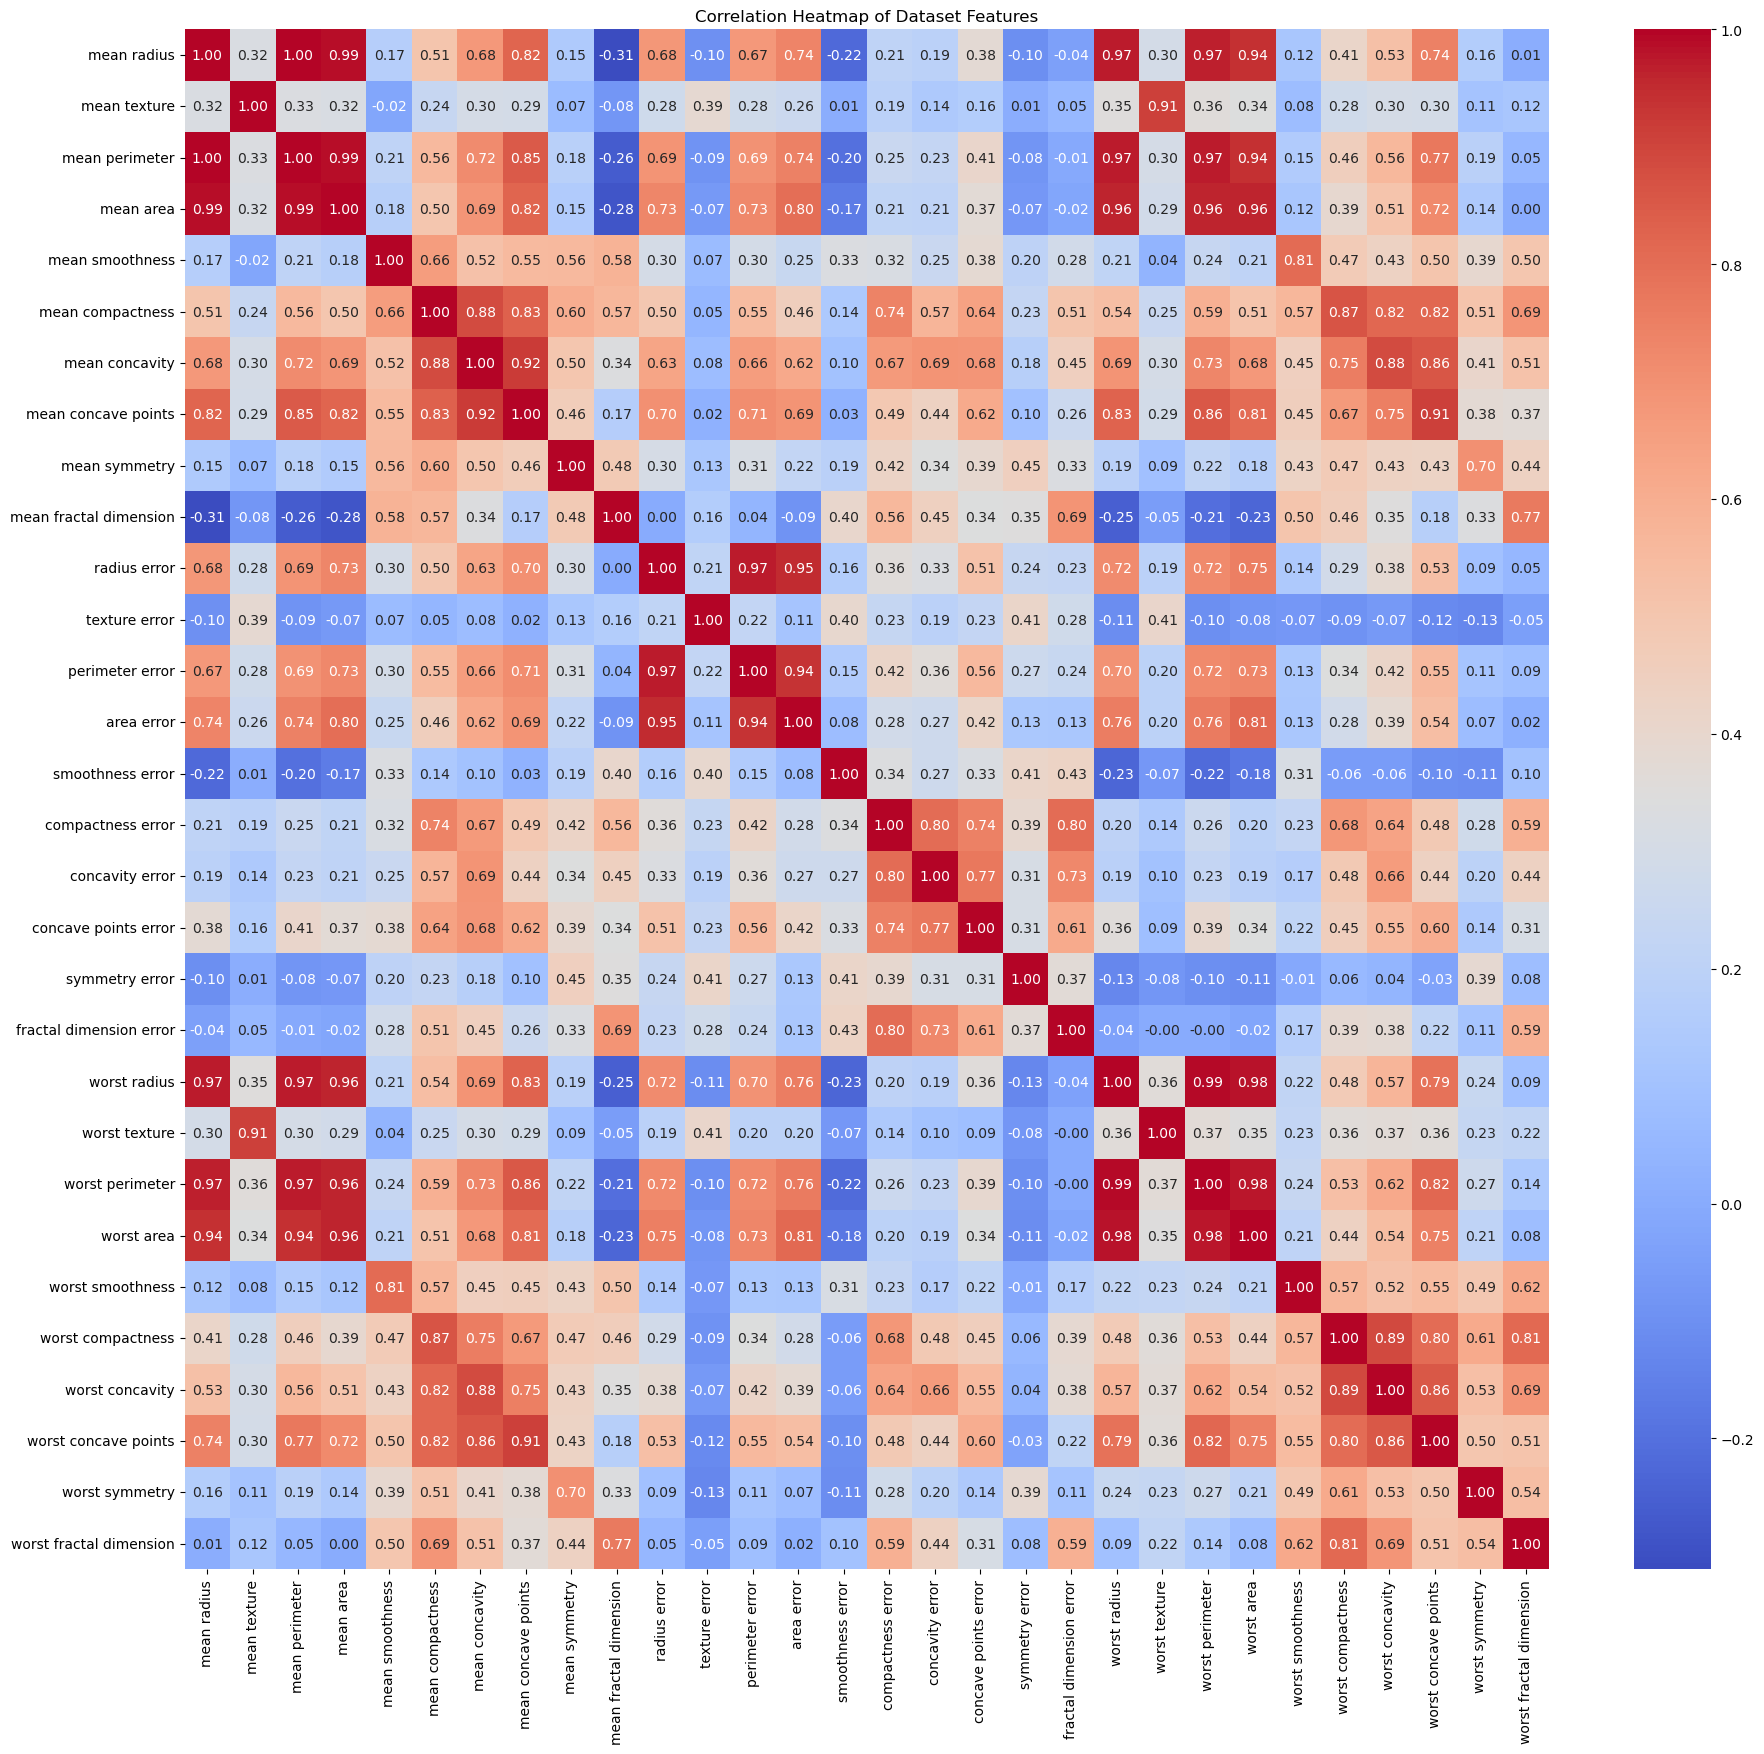

In [13]:
# correlation among features/ which features are closely related to each other
corr_matrix=X.corr()
plt.figure(figsize=(22, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of Dataset Features")
plt.show()

In [14]:
key_features=['mean radius', 'mean texture', 'mean smoothness', 'mean area']


>### Histograms

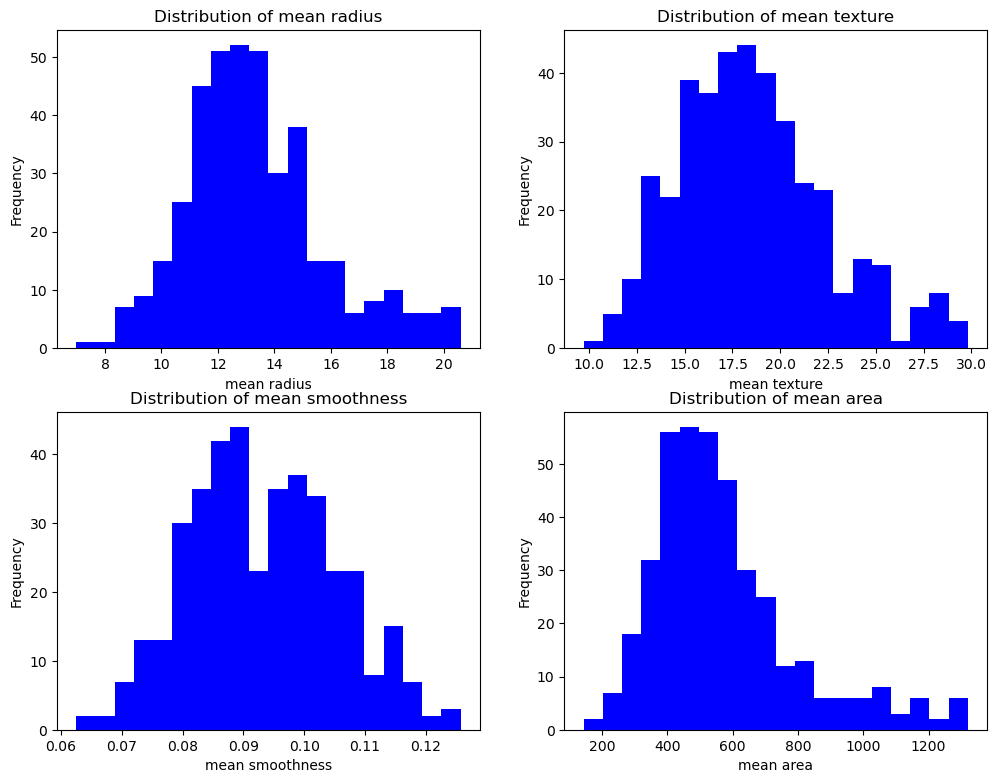

In [15]:
# histograms to visualize frequency distribution of each feature
plt.figure(figsize=(12, 19))
for i, col in enumerate(key_features, 1):
    plt.subplot(4, 2, i)
    plt.hist(df[col], bins=20, color='blue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.show()
 


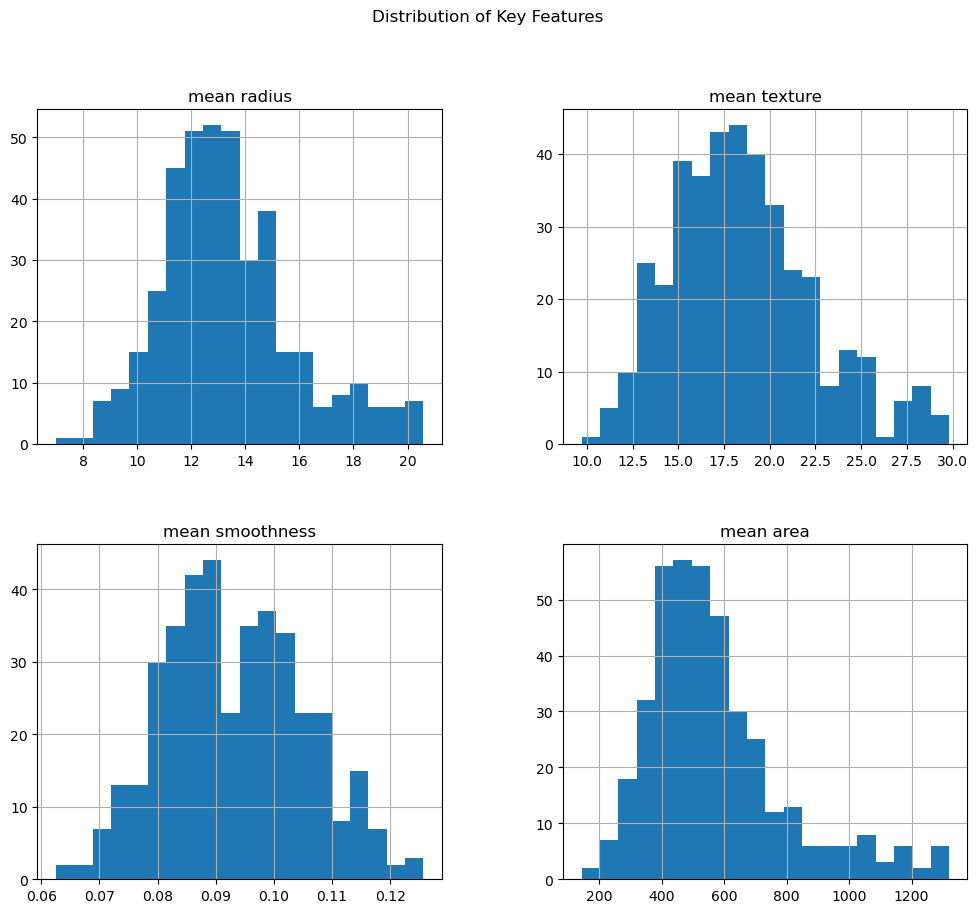

In [16]:
df[key_features].hist(figsize=(12, 10), bins=20)
plt.suptitle("Distribution of Key Features")
plt.show()

>### Boxplot For Outlier Detection

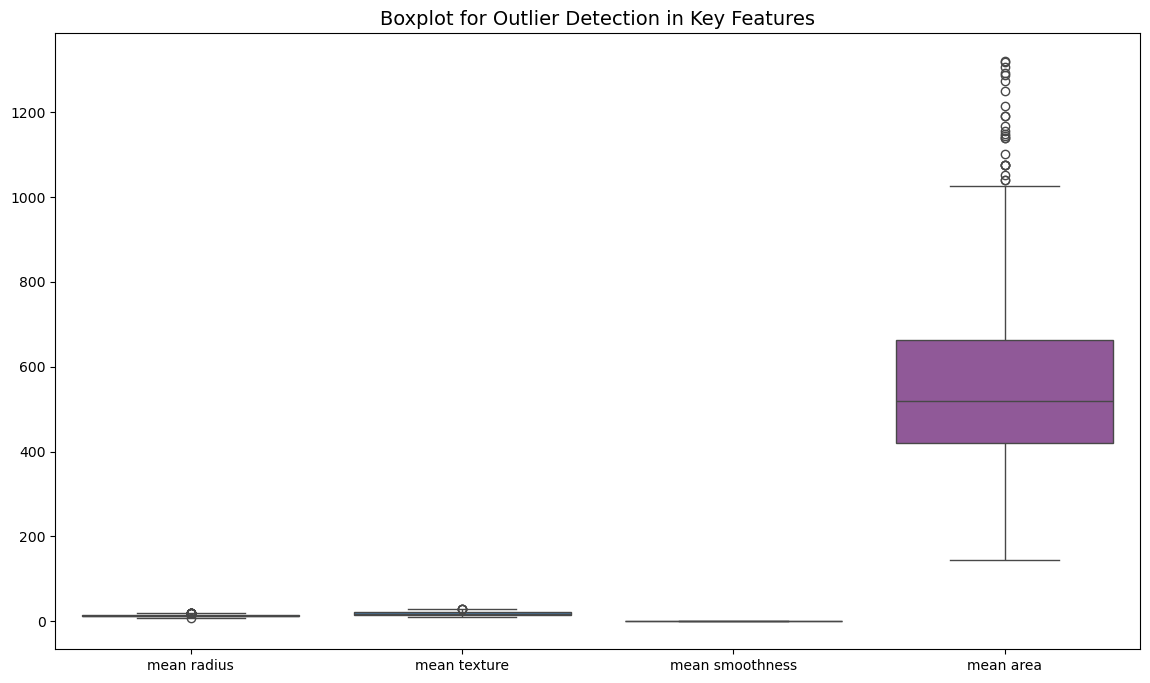

In [17]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[key_features], orient='v', palette='Set1')
plt.title("Boxplot for Outlier Detection in Key Features", fontsize=14)
plt.show()


>### Pairplot to Examine Relationship Among Key Features

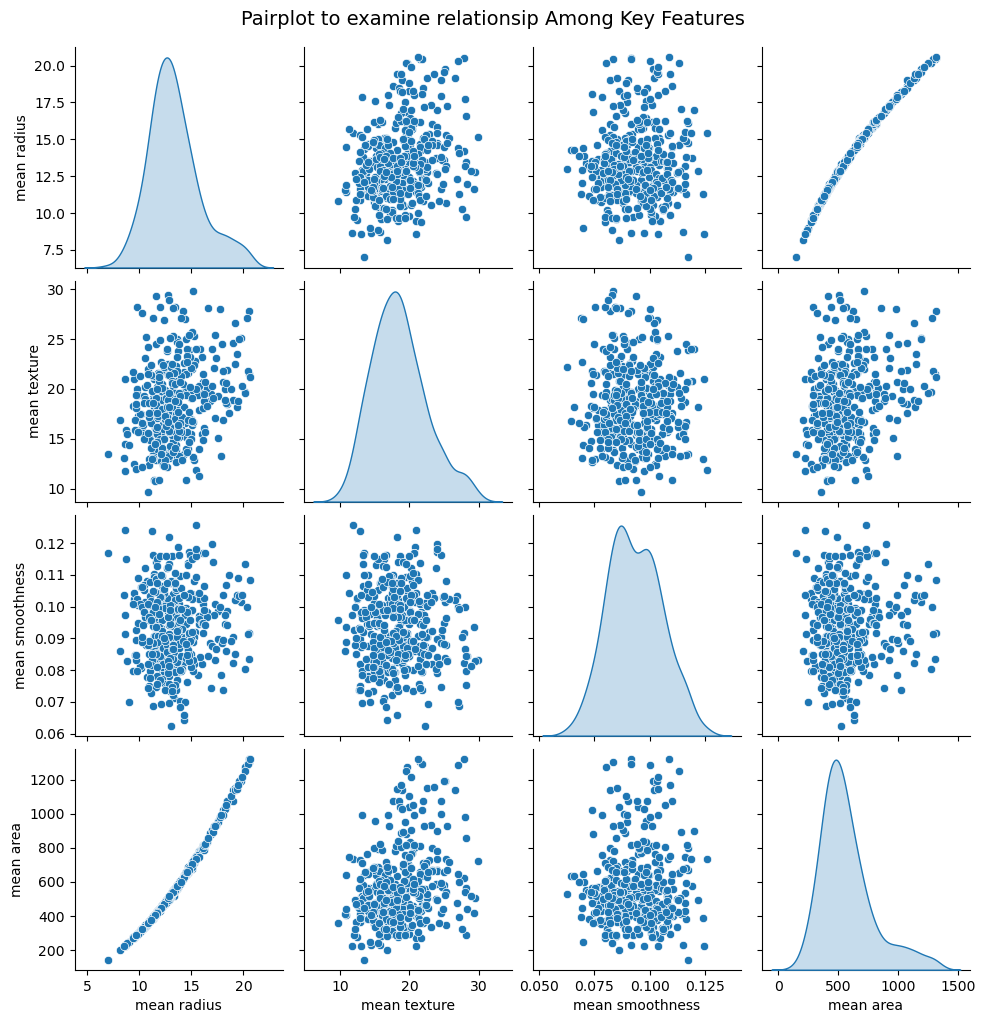

In [18]:
sns.pairplot(df[key_features], diag_kind='kde')
plt.suptitle("Pairplot to examine relationsip Among Key Features", y=1.02, fontsize =14)
plt.show()

# Preprocessing
> ### Log/ Square-Root transformations
Performs feature transformation
### Log Transformations:
Compresses right skewed data.
Reduces effect of very large values (outliers).
### Square-root Transformation:
Weaker than Log Transformation.
Helps with moderate skewness.

In [19]:
for col in key_features:
    if(df[col]>0).all():
        df[col+'_log']=np.log(df[col])
for col in key_features:
    if(df[col]>=0).all():
        df[col+'_sqrt']=np.sqrt(df[col])

In [20]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna()
const_cols=[col for col in df.columns if df[col].nunique()==1] # remove columns with single values in every row/ constant columns
df.drop(columns=const_cols, inplace=True)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst fractal dimension,Outcome,mean radius_log,mean texture_log,mean smoothness_log,mean area_log,mean radius_sqrt,mean texture_sqrt,mean smoothness_sqrt,mean area_sqrt
6,18.25,19.98,119.6,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,0.08368,0,2.904165,2.994732,-2.357781,6.946976,4.272002,4.469899,0.307620,32.249031
7,13.71,20.83,90.2,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,0.11510,0,2.618125,3.036394,-2.129472,6.359401,3.702702,4.563989,0.344819,24.039551
10,16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,0.08452,0,2.773838,3.145875,-2.500305,6.681858,4.002499,4.820788,0.286461,28.245354
11,15.78,17.89,103.6,781.0,0.09710,0.12920,0.09954,0.06606,0.1842,0.06082,...,0.10480,0,2.758743,2.884242,-2.332014,6.660575,3.972405,4.229657,0.311609,27.946377
13,15.85,23.95,103.7,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,0.05338,...,0.06287,0,2.763170,3.175968,-2.476819,6.662749,3.981206,4.893874,0.289845,27.976776


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,398.0,13.376209,2.484104,6.981000,11.710000,12.995000,14.640000,20.590000
mean texture,398.0,18.505879,3.911148,9.710000,15.702500,18.175000,20.755000,29.810000
mean perimeter,398.0,86.403266,16.841597,43.790000,75.065000,84.065000,94.730000,137.800000
mean area,398.0,570.547990,222.883241,143.500000,420.350000,518.300000,664.200000,1320.000000
mean smoothness,398.0,0.093271,0.012066,0.062510,0.084520,0.092385,0.101750,0.125700
mean compactness,398.0,0.086260,0.034979,0.019380,0.059592,0.079455,0.108975,0.202200
mean concavity,398.0,0.060442,0.049068,0.000000,0.025628,0.045580,0.083572,0.254500
mean concave points,398.0,0.035902,0.025625,0.000000,0.018640,0.028295,0.049478,0.125900
mean symmetry,398.0,0.173639,0.020819,0.116700,0.159000,0.172250,0.188500,0.245900
mean fractal dimension,398.0,0.061211,0.005015,0.049960,0.057337,0.060855,0.064213,0.078180


>### Splitting Data into Training and Testing Sets

In [22]:
x_train, x_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sc=StandardScaler()
x_tr_scaled=sc.fit_transform(x_train)
x_te_scaled=sc.transform(x_test)


# Model Training and Evaluation

In [89]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
def binary_cross_entropy(y_true, y_pred):
    y_true=np.array(y_true)
    y_pred=np.array(y_pred)
    eps=1e-15
    y_pred=np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

>### Logistic Regression Model

In [90]:
class LogisticRegressionModel:
    def __init__(self, l_r=0.01, n_iter=1000):
        self.l_r=l_r
        self.n_iter=n_iter
        self.weights=None
        self.bias=None
    def fit(self, x, y):
        x=np.array(x)
        y=np.array(y)

        n_samples, n_features=x.shape
        self.weights=np.zeros(n_features)
        self.bias=0
        
        for _ in range(self.n_iter):
            linear_model=np.dot(x, self.weights)+self.bias
            y_predicted=sigmoid(linear_model)
            dw=(1/n_samples)*np.dot(x.T, (y_predicted-y))
            db=(1/n_samples)*np.sum(y_predicted-y)
            self.weights-=self.l_r*dw
            self.bias-=self.l_r*db
    def predict_proba(self, x):
        x=np.array(x)
        linear_model=np.dot(x, self.weights)+self.bias
        return sigmoid(linear_model)
    def predict(self, x):
        proba=self.predict_proba(x)
        return np.where(proba>=0.5, 1, 0)

In [ ]:
print("Logistic Regression Model")
log_model=LogisticRegressionModel(l_r=0.001, n_iter=10000)
log_model.fit(x_tr_scaled, y_train)
log_predicted=log_model.predict(x_te_scaled)
log_acc=accuracy_score(y_test, log_predicted)
print("Accuracy of Logistic Regression Model: ", log_acc)
print("Classification Report:")
print(classification_report(y_test, log_predicted))


Logistic Regression Model
Accuracy of Logistic Regression Model 0.9736842105263158
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



>### Neural Network Model (Single Neuron Neural Network)
Initialize with number of features

1- Call fit() → trains weights and bias

2- Call predict_proba() → get predicted probabilities

3- Call predict() → get 0/1 predictions for evaluation

In [92]:
class NN:
    def __init__(self, n_features, lr=0.01):
        # initialize weights and bias
        self.w=np.ones(n_features)
        self.b=0.0
        self.lr=lr
        
    def forward(self, X): # compute output of the neuron/ weighted sum
        z=np.dot(X, self.w)+self.b
        return sigmoid(z)
    def compute_gradients(self, X, y, y_pred): # compute gradients for weights and bias
        n_samples = X.shape[0] #X=np.array, shape(n_samples, n_features)
        y = y.reshape(-1, 1) #y=np.array, shape(n_samples,)
        y_pred = y_pred.reshape(-1, 1) #y_pred=np.array, shape(n_samples,)
        
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = np.mean(y_pred - y)
        
        return dw.flatten(), db # flatten dw to match weight vector shape

    def fit(self, X, y, epochs=2000, threshold=0.25): # train the single neuron using gradient descent
        for epoch in range (epochs): # epochs= number of iterations
            y_pred=self.forward(X)
            loss=binary_cross_entropy(y, y_pred)
            dw, db =self.compute_gradients(X,y, y_pred)
            self.w=self.w-self.lr*dw
            self.b=self.b-self.lr*db
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss={loss:.5f}") # print progrss after evey 100 epochs
            if loss<= threshold:
                print(f"Stopped early at epoch {epoch}, Loss={loss:.5f}")
                break
        print("\nFinal learned parameters:")
        print("Weights", self.w)
        print("Bias: ", self.b)
    def predict(self, X):
        probs=self.forward(X)
        return np.where(probs>=0.5, 1, 0)
    

In [93]:
nn_model=NN(n_features=x_tr_scaled.shape[1], lr=0.01)


In [94]:
nn_model.fit(x_tr_scaled, y_train, epochs=3000, threshold=0.1)

Epoch 0, Loss=13.84679
Epoch 100, Loss=6.36916
Epoch 200, Loss=1.06563
Epoch 300, Loss=0.31511
Epoch 400, Loss=0.20775
Epoch 500, Loss=0.16986
Epoch 600, Loss=0.14924
Epoch 700, Loss=0.13553
Epoch 800, Loss=0.12546
Epoch 900, Loss=0.11764
Epoch 1000, Loss=0.11137
Epoch 1100, Loss=0.10622
Epoch 1200, Loss=0.10192
Stopped early at epoch 1251, Loss=0.10000

Final learned parameters:
Weights [-0.24374584 -0.34899811 -0.29304828 -0.25567655 -0.15842037 -0.41407933
 -0.57732403 -0.6474931  -0.13322271  0.4731902  -0.42766588  0.28462365
 -0.360783   -0.26855023  0.30829329  0.00694412  0.1639854  -0.24821405
  0.30778381  0.34675999 -0.39470829 -0.4392274  -0.41456264 -0.35644391
 -0.22902019 -0.29628956 -0.42220535 -0.59762993 -0.17066193  0.00867219]
Bias:  0.6061910943705194


In [95]:
nn_pred=nn_model.predict(x_te_scaled)
nn_acc=accuracy_score(y_test, nn_pred.flatten())
print("\nAccuracy: ", nn_acc)
print("Clasification Report:")
print(classification_report(y_test, nn_pred.flatten()))


Accuracy:  0.956140350877193
Clasification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

